In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
import matplotlib.pyplot as plt
import numpy as np
import suite2p

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  16 16:24:40 2024

@author: rbilek
"""


#parameter dictionary with explanations
ops ={
        # Suite2p version
        "suite2p_version": '0.14.4',  #current version of suite2p used for pipeline

        # main settings
        "nplanes": 1,  # each tiff has these many planes in sequence !!!!
        "nchannels": 1,  # each tiff has these many channels per plane !!!!
        "functional_chan": 1,  # this channel is used to extract functional ROIs (1-based)
        "tau": 1.5, # this is the main parameter for deconvolution, default is 1 but should be 1.25-1.5 for GCaMP6s
        "fs": 29.94, # sampling rate, default is 10  !!!!!
        "force_sktiff": False,  # whether or not to use scikit-image for tiff reading
        "frames_include": -1,
        "multiplane_parallel": False,  # whether or not to run on server
        "ignore_flyback": [], #specifies which planes will be ignored as flyback planes by the pipeline.

        # output settings
        "preclassify": 0.0,  # apply classifier before signal extraction with probability 0.3
        "combined": True,  # combine multiple planes into a single result /single canvas for GUI
        "aspect": 1.0,  # um/pixels in X / um/pixels in Y (for correct aspect ratio in GUI)

        # registration settings
        "do_registration": True,  # whether to register data (2 forces re-registration)
        "two_step_registration": True,  # whether or not to run registration twice (useful for low SNR data). Set keep_movie_raw to True if setting this parameter to True.
        "keep_movie_raw": False,  # whether to keep binary file of non-registered frames.
        "nimg_init": 300,  # how many frames to use to compute reference image for registration
        "batch_size": 700,  # how many frames to register simultaneously in each batch. This depends on memory constraints - it will be faster to run if the batch is larger, but it will require more RAM.
        "maxregshift": 0.1,  # max allowed registration shift, as a fraction of frame max(width and height)
        "align_by_chan": 1,  # when multi-channel, you can align by non-functional channel (1-based)
        "reg_tif": True ,  # whether to save registered tiffs
        "reg_tif_chan2": False,  # whether to save channel 2 registered tiffs
        "subpixel": 10,  # precision of subpixel registration (1/subpixel steps)
        "smooth_sigma_time": 0,  # gaussian smoothing in time
        "smooth_sigma": 1.15,  # ~1 good for 2P recordings, recommend 3-5 for 1P recordings
        "th_badframes": 1.0,  # this parameter determines which frames to exclude when determining cropping - set it smaller to exclude more frames
        "norm_frames": True,  # normalize frames when detecting shifts
        "force_refImg": False,  # if True, use refImg stored in ops if available
        "pad_fft": False,  # if True, pads image during FFT part of registration

        # non rigid registration settings
        "nonrigid": True,  # whether to use nonrigid registration
        "block_size": [128, 128],  # size of blocks for non-rigid registration, in pixels (** keep this a multiple of 2 **)
        "snr_thresh": 1.2,  # if any nonrigid block is below this threshold, it gets smoothed until above this threshold. 1.0 results in no smoothing
        "maxregshiftNR": 5,  # maximum pixel shift allowed for nonrigid, relative to rigid

        # cell detection settings with suite2p
        "roidetect": True,  # whether or not to run ROI extraction
        "spikedetect": True,  # whether or not to run spike deconvolution
        "sparse_mode": True,  # whether or not to run sparse_mode
        "spatial_scale": 0,  # 0: multi-scale; 1: 6 pixels, 2: 12 pixels, 3: 24 pixels, 4: 48 pixels
        "connected": True,  # whether or not to keep ROIs fully connected (set to 0 for dendrites)
        "nbinned": 5000,  # max number of binned frames for cell detection
        "max_iterations": 20,  # maximum number of iterations to do cell detection
        "threshold_scaling": 1.0,  # adjust the automatically determined threshold by this scalar multiplier
        "max_overlap": 0.75,  # cells with more overlap than this get removed during triage, before refinement
        "high_pass": 100,  # running mean subtraction across bins with a window of size "high_pass" (use low values for 1P)
        "spatial_hp_detect": 25,  # window for spatial high-pass filtering for neuropil subtraction before detection
        "denoise": True,  # denoise binned movie for cell detection in sparse_mode

        # classification parameters
        "soma_crop": True,  # crop dendrites for cell classification stats like compactness
        # ROI extraction parameters
        "neuropil_extract": True,  # whether or not to extract neuropil; if False, Fneu is set to zero
        "inner_neuropil_radius": 2,  # number of pixels to keep between ROI and neuropil donut
        "min_neuropil_pixels": 350,  # minimum number of pixels in the neuropil
        "lam_percentile": 50.,  # percentile of lambda within area to ignore when excluding cell pixels for neuropil extraction
        "allow_overlap": False,  # pixels that are overlapping are thrown out (False) or added to both ROIs (True)

        # cell detection settings with cellpose (used if anatomical_only > 0)
        "anatomical_only": 4,  # run cellpose to get masks on 1: max_proj / mean_img; 2: mean_img; 3: mean_img enhanced, 4: max_proj
        "diameter": 0,  # use diameter for cellpose, if 0 estimate diameter
        "cellprob_threshold": 0.0,  # cellprob_threshold for cellpose
        "flow_threshold": 1.5,  # flow_threshold for cellpose
        "spatial_hp_cp": 0,  # high-pass image spatially by a multiple of the diameter
        "pretrained_model":
        "cyto",  # path to pretrained model or model type string in Cellpose (can be user model)

        # channel 2 detection settings (stat[n]["chan2"], stat[n]["not_chan2"])
        # "chan2_thres": 0.65,  # minimum for detection of brightness on channel 2

        # deconvolution settings
        "baseline": "maximin",  # baselining mode (can also choose "prctile")
        "win_baseline": 60.,  # window for maximin
        "sig_baseline": 10.,  # smoothing constant for gaussian filter
        "prctile_baseline": 8.,  # optional (whether to use a percentile baseline)
        "neucoeff": 0.7,  # neuropil coefficient
    }





In [3]:
## to run preprocessing on specific files

from pathlib import Path
raw_path =Path('/vol/battaglialab/imaging1/Veronique/tests/blinking/screen_left_right_center_right/')
save_path = '/vol/battaglialab/imaging1/Veronique/tests/blinking/screen_left_right_center_right/'
db = {
    "fast_disk": '/scratch/vstokkers/data/temp/',  # used to store temporary binary files, defaults to save_path0
    "delete_bin": False,  # whether to delete binary file after processing
    "move_bin": True,  # if 1, and fast_disk is different than save_disk, binary file is moved to save_disk
    "data_path": [raw_path],
    "save_folder": f'{save_path}',  # directory you'd like Suite2p results to be saved to
}
output_ops = suite2p.run_s2p(ops=ops, db=db)


{'fast_disk': '/scratch/vstokkers/data/temp/', 'delete_bin': False, 'move_bin': True, 'data_path': [PosixPath('/vol/battaglialab/imaging1/Veronique/tests/blinking/screen_left_right_center_right')], 'save_folder': '/vol/battaglialab/imaging1/Veronique/tests/blinking/screen_left_right_center_right/'}
tif
** Found 1 tifs - converting to binary **
time 8.54 sec. Wrote 1666 frames per binary for 1 planes
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying default /home/vstokkers/.suite2p/classifiers/classifier_user.npy
----------- REGISTRATION
Reference frame, 5.98 sec.
Registered 700/1666 in 9.25s
Registered 1400/1666 in 18.28s
Registered 1666/1666 in 21.86s
----------- Total 37.13 sec
Registration metrics, 7.84 sec.
----------- ROI DETECTION
Binning movie in chunks of length 45
Binned movie of size [37,482,484] created in 0.30 sec.
Binned movie denoised (for cell 

/scratch/vstokkers/miniconda3/envs/suite2pMini/lib/python3.9/site-packages/suite2p/extraction/extract.py:125: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  Fi[n] = np.dot(data[:, cell_ipix[n]], cell_lam[n])


Extracted fluorescence from 88 ROIs in 1666 frames, 10.07 sec.
----------- Total 15.91 sec.
----------- CLASSIFICATION
['npix_norm', 'compact', 'skew']
----------- SPIKE DECONVOLUTION
----------- Total 0.01 sec.
moving binary files to save_path
Plane 0 processed in 68.15 sec (can open in GUI).
total = 81.52 sec.
TOTAL RUNTIME 81.52 sec


In [8]:
import os 
import numpy as np
path = '/vol/battaglialab/imaging1/Veronique/tests/blinking/screen_leftright/plane0'  # Windows


# Load ops from that path
ops = np.load(os.path.join(path, 'ops.npy'), allow_pickle=True).item()

# The mean image
mean_img = ops['meanImg']

# There may also be:
mean_img_e = ops.get('meanImgE')  # Enhanced mean image (if computed)

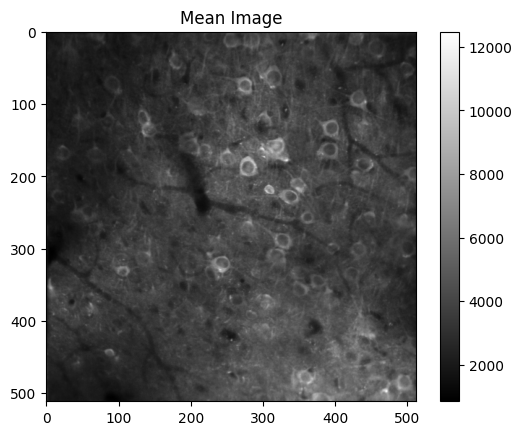

In [9]:
plt.imshow(mean_img, cmap='gray')
plt.colorbar()
plt.title('Mean Image')
plt.show()